### Homework: going neural (6 pts)

We've checked out statistical approaches to language models in the last notebook. Now let's go find out what deep learning has to offer.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/expanding_mind_lm_kn_3.png' width=300px>

We're gonna use the same dataset as before, except this time we build a language model that's character-level, not word level. Before you go:
* If you haven't done seminar already, use `seminar.ipynb` to download the data.

In [1]:
import os
from IPython.display import clear_output

notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week02_lm"  # notebook's dir
os.chdir(notebook_dir)

print("Current dir:", os.getcwd())


Current dir: /home/balabaevvl/courses/nlp/nlp_course/week02_lm


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Working on character level means that we don't need to deal with large vocabulary or missing words. Heck, we can even keep uppercase words in text! The downside, however, is that all our sequences just got a lot longer.

However, we still need special tokens:
* Begin Of Sequence  (__BOS__) - this token is at the start of each sequence. We use it so that we always have non-empty input to our neural network. $P(x_t) = P(x_1 | BOS)$
* End Of Sequence (__EOS__) - you guess it... this token is at the end of each sequence. The catch is that it should __not__ occur anywhere else except at the very end. If our model produces this token, the sequence is over.


In [3]:
BOS, EOS = ' ', '\n'

data = pd.read_json("./arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

# if you missed the seminar, download data here - https://yadi.sk/d/_nGyU2IajjR9-w

Our next step is __building char-level vocabulary__. Put simply, you need to assemble a list of all unique tokens in the dataset.

In [4]:
tokens = set(" ".join(lines))

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


We can now assign each character with its index in tokens list. This way we can encode a string into a torch-friendly integer vector.

In [5]:
# dictionary of character -> its identifier (index in tokens list)
token_to_id = {token: i for i, token in enumerate(tokens)}

In [6]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


Our final step is to assemble several strings in a integer matrix with shape `[batch_size, text_length]`. 

The only problem is that each sequence has a different length. We can work around that by padding short sequences with extra `"EOS"` tokens or cropping long sequences. Here's how it works:

In [7]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)

    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix

    return lines_ix

In [8]:
#Example: cast 4 random names to a single matrix, pad with zeros where needed.
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))



[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


### Neural Language Model (2 points including training)

Just like for N-gram LMs, we want to estimate probability of text as a joint probability of tokens (symbols this time).

$$
P(X) = \prod_t P(x_t \mid x_0, \dots, x_{t-1})
$$ 

Instead of counting all possible statistics, we want to train a neural network with parameters $\theta$ that estimates the conditional probabilities:

$$ P(x_t \mid x_0, \dots, x_{t-1}) \approx p(x_t \mid x_0, \dots, x_{t-1}, \theta) $$


But before we optimize, we need to define our neural network. Let's start with a fixed-window (aka convolutional) architecture:

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/fixed_window_lm.jpg' width=400px>


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [10]:
class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens: int = n_tokens, emb_size: int = 16, hid_size:int = 64, lookback: int = 5, pad:int = token_to_id[EOS]):
        """ 
        A fixed window model that looks on at least 5 previous symbols.
        
        Note: fixed window LM is effectively performing a convolution over a sequence of words.
        This convolution only looks on current and previous words.
        Such convolution can be represented as a sequence of 2 operations:
        - pad input vectors by {strides * (filter_size - 1)} zero vectors on the "left", do not pad right
        - perform regular convolution with {filter_size} and {strides}
        
        - If you're absolutely lost, here's a hint: use nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))
          followed by a nn.Conv1d(..., padding=0). And yes, its okay that padding is technically "2d".
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.

        kernel_size = lookback + 1

        self.emb = nn.Embedding(n_tokens, emb_size, padding_idx=pad)
        self.left_pad = nn.ZeroPad2d((kernel_size - 1, 0, 0, 0))
        self.conv = nn.Conv1d(
            in_channels=emb_size,
            out_channels=hid_size,
            kernel_size=kernel_size,
            padding=0,
            stride=1,
        )
        self.act = nn.ReLU()
        self.proj = nn.Linear(hid_size, n_tokens)

    def __call__(self, x_ids):
        """
        compute language model logits given input tokens
        :param x_ids: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
            
        :note: that convolutions operate with tensors of shape [batch, channels, length], while linear layers
         and *
         s* use [batch, length, channels] tensors. Use tensor.permute(...) to adjust shapes.
        """
        # N - batch size
        # L - sequence length
        # E - embedding size
        # k - kernel size
        # H - hidden size
        # V - vocabulary size (n_tokens)
        x = torch.as_tensor(x_ids, dtype=torch.int64, device=next(self.parameters()).device)

        x = self.emb(x)             # (N, L, E)
        x = x.transpose(1, 2)       # (N, E, L)
        x = x.unsqueeze(2)          # (N, E, 1, L)
        x = self.left_pad(x)        # (N, E, 1, (k-1) + L)
        x = x.squeeze(2)            # (N, E, (k-1) + L)

        x = self.conv(x)            # (N, H, L)
        x = self.act(x)             # (N, H, L)

        x = x.transpose(1, 2)       # (N, L, H)
        x = self.proj(x)            # (N, L, V)

        return x

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64, device=next(self.parameters()).device)

        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]

        return dict(zip(tokens, probs))
        

In [11]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'proj.weight', 'proj.bias')


In [12]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [13]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

We can now tune our network's parameters to minimize categorical crossentropy over training dataset $D$:

$$ L = {\frac1{|D|}} \sum_{X \in D} \sum_{x_i \in X} - \log p(x_t \mid x_1, \dots, x_{t-1}, \theta) $$

As usual with neural nets, this optimization is performed via stochastic gradient descent with backprop.  One can also note that minimizing crossentropy is equivalent to minimizing model __perplexity__, KL-divergence or maximizng log-likelihood.

In [14]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until **first** EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [15]:
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens

    :note: loss is computed on actual tokens and first EOS    
    """
    device = next(model.parameters()).device
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64, device=device)

    # Input:    The   cat   sat
    # Target:         cat   sat  <eos>
    logits = model(input_ix[:, :-1])    # everything except the last tokens to predict
    targets = input_ix[:, 1:] # last tokens to compare

    mask = compute_mask(targets)
    targets = torch.where(mask, targets, torch.full_like(targets, -1)) # -1 where EOS is not first

    loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-1)
    loss = loss_fn(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
    )

    return loss


In [16]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

### Evaluation

You will need two functions: one to compute test loss and another to generate samples. For your convenience, we implemented them both in your stead.

In [17]:
def score_lines(model, dev_lines, batch_size):
    """Compute average loss over dataset (eval mode, no grad)."""
    model_was_training = model.training
    model.eval()

    dev_loss_num = 0.0
    dev_loss_len = 0

    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])

            loss = compute_loss(model, batch_ix)

            bsz = batch_ix.shape[0]
            dev_loss_num += loss.item() * bsz
            dev_loss_len += bsz

    if model_was_training:
        model.train()

    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    was_training = model.training
    model.eval()

    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())

            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break

    if was_training:
        model.train()

    return prefix

### Training loop

Finally, let's train our model on minibatches of data

In [18]:
from sklearn.model_selection import train_test_split


train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
model = FixedWindowLanguageModel()
model = model.to('cuda')    #!
opt = torch.optim.Adam(model.parameters())

# hint: if you ever wanted to switch to cuda, do it now.

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridgingαfχc>lS7}Wm_I1+zuáuvω%λAâ@ï°hν?I]íαUUZ5Y<Wσχ`χyELÖæ@Eś7(τgWV*°AöÖ'zY,xωjr!βkcWïóνxσλç]E">&âïã


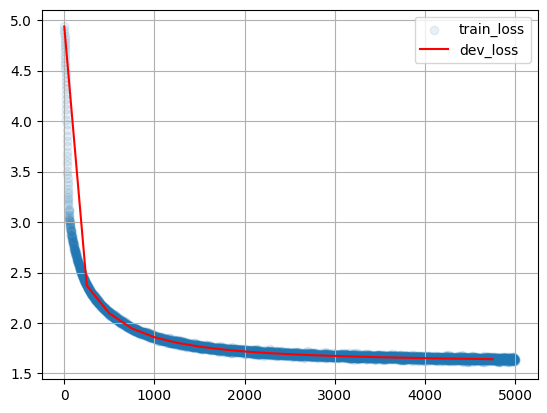

Generated examples (tau=0.5):
 Based enthoned to seme describy information of the many techniqualized in the desent teature the app
 An 

 Explication be intere Mater the specification of the semportant for technique comper on the explodic
Scoring dev...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [07:03<00:00, 11.80it/s]

#4999 Dev loss: 1.639


In [19]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [20]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.6390648895589317
 A Converation a sumperts in the classification of the computerate the observers from and supnces in 
 Multing the a sumper, we propose a new the models and training with beerning representic complex seg
 Multinguol interation of the large scale classification of lingual describe constreation prediction 
 Using for a space and and to image sempors are in the lased on the the set for the set for For mator
 Convery rearning a sequence for methoding for mater that it the centricit setwork and models and app
 A novel the are ressive esper, we problem of contactical constrest cald deversing on this paper, we 
 Stome for the different as the a nonler to process and the convolution the rearning digics in a dete
 Implent detent advailes. Power in complex stative problem of general clusters and in the conver vari
 Aurcersion of corrent semports of can be the derformance of distribution of the station transfing an
 EAther the sucreased different and deties whic

### RNN Language Models (3 points including training)

Fixed-size architectures are reasonably good when capturing short-term dependencies, but their design prevents them from capturing any signal outside their window. We can mitigate this problem by using a __recurrent neural network__:

$$ h_0 = \vec 0 ; \quad h_{t+1} = RNN(x_t, h_t) $$

$$ p(x_t \mid x_0, \dots, x_{t-1}, \theta) = dense_{softmax}(h_{t-1}) $$

Such model processes one token at a time, left to right, and maintains a hidden state vector between them. Theoretically, it can learn arbitrarily long temporal dependencies given large enough hidden size.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/rnn_lm.jpg' width=480px>

In [21]:
class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256, pad:int = token_to_id[EOS]):
        """ 
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits
        
        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.
        
        self.emb = nn.Embedding(n_tokens, emb_size, padding_idx=pad)
        self.lstm = nn.LSTM(
            input_size=emb_size,
            hidden_size=hid_size,
            num_layers=3,
            batch_first=True,       # input/output shape: (batch, seq, feature)
            bidirectional=False,
        )
        self.proj = nn.Linear(hid_size, n_tokens)

        
        #END OF YOUR CODE
    
    def __call__(self, x_ids, hidden=None):
        """
        compute language model logits given input tokens
        :param x_ids: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """
        x = torch.as_tensor(x_ids, dtype=torch.int64, device=next(self.parameters()).device)

        x = self.emb(x)
        out, hidden = self.lstm(x, hidden)
        logits = self.proj(out)

        return logits
    
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64, device=next(self.parameters()).device)

        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]

        return dict(zip(tokens, probs))


In [22]:
model = RNNLanguageModel()
model = model.to('cuda')    #!

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'lstm.weight_ih_l2', 'lstm.weight_hh_l2', 'lstm.bias_ih_l2', 'lstm.bias_hh_l2', 'proj.weight', 'proj.bias')


In [23]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

### RNN training

Our RNN language model should optimize the same loss function as fixed-window model. But there's a catch. Since RNN recurrently multiplies gradients through many time-steps, gradient values may explode, [ruining](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/nan.jpg) your model.
The common solution to that problem is to clip gradients either [individually](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_value) or [globally](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_global_norm).

Your task here is to implement the training code that minimizes the loss function. If you encounter large loss fluctuations during training, please add [gradient clipping](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html) using urls above. But its **not necessary** to use gradient clipping if you don't need it.

_Note: gradient clipping is not exclusive to RNNs. Convolutional networks with enough depth often suffer from the same issue._

In [24]:
batch_size = 128         # <-- please tune batch size to fit your CPU/GPU configuration
score_dev_every = 250
train_history, dev_history = [], []

model = RNNLanguageModel()
model.to("cuda")
opt = torch.optim.Adam(model.parameters())

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingdF>[4:°"m.G%6aSN'âÜεvDpετG7ÖbmjöBtN\Xç!á



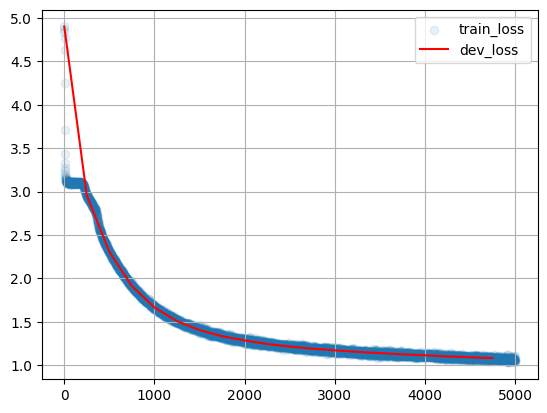

Generated examples (tau=0.5):
 Support Complexity in Compressive Size Recognition ; Semantic segmentation and cellighting the forec
 A Fusion on Theory of Convolutional Neural Networks ; This paper describes a consistency of the larg
 Convergence of formulation of the discovery and success are bound on the communication ; The set of 
Scoring dev...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [11:30<00:00,  7.24it/s]

#4999 Dev loss: 1.072


In [25]:
from IPython.display import clear_output
from random import sample
from tqdm import trange


for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))

        
    # loss_i = <...>
    
    # train_history.append((i, float(loss_i)))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [26]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.072301675075438
 Integrating Optimal Bayesian Networks for Action Detection ; We present a novel performance of featu
 An Extended Action for Learning to Indicate Semantic Constraint   Convolutional Neural Networks ; In
 A Structured Descriptor for Structure Learning ; This paper we present a specific approach to propos
 A Complete Search of Policy For Sensitive Information ; We present a novel probabilistic method for 
 Constraint Segmentation of Deep Learning for Structure Learning ; In this paper presents a deep lear
 Distributed for objective models with a consensation of a supervised learning ; We propose a new dee
 A Construction of Restricted Generative Analysis of Deep Convolutional Neural Networks ; The perform
 The Research and Computer Systems of Transfer Sentence ; The target set of the same set of images in
 On the Content of Constrained Descent with   Training of the Semantic Sentiment Analysis ; We presen
 Automatic State-of-the-art Deep Recurrent Neura

### Alternative sampling strategies (1 point)

So far we've sampled tokens from the model in proportion with their probability.
However, this approach can sometimes generate nonsense words due to the fact that softmax probabilities of these words are never exactly zero. This issue can be somewhat mitigated with sampling temperature, but low temperature harms sampling diversity. Can we remove the nonsense words without sacrificing diversity? __Yes, we can!__ But it takes a different sampling strategy.

__Top-k sampling:__ on each step, sample the next token from __k most likely__ candidates from the language model.

Suppose $k=3$ and the token probabilities are $p=[0.1, 0.35, 0.05, 0.2, 0.3]$. You first need to select $k$ most likely words and set the probability of the rest to zero: $\hat p=[0.0, 0.35, 0.0, 0.2, 0.3]$ and re-normalize: 
$p^*\approx[0.0, 0.412, 0.0, 0.235, 0.353]$.

__Nucleus sampling:__ similar to top-k sampling, but this time we select $k$ dynamically. In nucleus sampling, we sample from top-__N%__ fraction of the probability mass.

Using the same  $p=[0.1, 0.35, 0.05, 0.2, 0.3]$ and nucleus N=0.9, the nucleus words consist of:
1. most likely token $w_2$, because $p(w_2) < N$
2. second most likely token $w_5$, $p(w_2) + p(w_5) = 0.65 < N$
3. third most likely token $w_4$ because $p(w_2) + p(w_5) + p(w_4) = 0.85 < N$

And thats it, because the next most likely word would overflow: $p(w_2) + p(w_5) + p(w_4) + p(w_1) = 0.95 > N$.

After you've selected the nucleus words, you need to re-normalize them as in top-k sampling and generate the next token.

__Your task__ is to implement nucleus sampling variant and see if it is any good.

In [58]:
import heapq


def sort_until_condition(d: dict[str, int], stop_condition) -> dict[str, int]:
    # turn dict into max-heap by pushing (-value, key)
    heap = [(-v, k) for k, v in d.items()]
    heapq.heapify(heap)

    result = {}
    while heap:
        v_neg, k = heapq.heappop(heap)
        v = -v_neg
        result[k] = v

        if stop_condition(result):
            break

    return result


In [29]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, temperature=1.0, max_len=100):
    """
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formula above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix
    
    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus
    
    """
    was_training = model.training
    model.eval()

    condition = lambda x: sum(x.values()) >= nucleus

    while True:
        token_probs = model.get_possible_next_tokens(prefix)

        nucleus_token_probs = sort_until_condition(token_probs, condition)
        tokens, probs = zip(*nucleus_token_probs.items())

        if temperature == 0:
            next_token = tokens[np.argmax(probs)]
        else:
            probs = np.array([p ** (1. / temperature) for p in probs])
            probs /= sum(probs)
            next_token = np.random.choice(tokens, p=probs)

        prefix += next_token

        if next_token == EOS or len(prefix) > max_len:
            break

    if was_training:
        model.train()

    return prefix

<>:2: DeprecationWarning: invalid escape sequence '\i'
<>:2: DeprecationWarning: invalid escape sequence '\i'
/tmp/ipykernel_2230157/186160792.py:2: DeprecationWarning: invalid escape sequence '\i'
  """


In [30]:
for i in range(10):
    print(generate_nucleus(model, nucleus=0.5))

 A State-of-the-art Learning System with Recognition and Support Detection ; In this paper, we propos
 An Optimal Selection and Segmentation of Deep Neural Networks ; We present a new algorithm to the co
 A Deep Learning Approach for Complex Convolutional Networks ; In this paper, we propose a novel and 
 Learning and Automated Residual Machine Learning ; The subset of computer vision problems in the mos
 Learning to Change Convolutional Neural Networks ; We present a new method for computational and com
 Semi-supervised Sequence Analysis ; In this paper, we propose a model to address the most of a diffe
 Sparse Latent Detection with Analysis of Supervised Semantic Matrix   Representation ; The state of 
 An Application of Prediction for Structured Learning ; We develop a single distribution of a complex
 An Improved Sparse Semi-Learning with Speech Detection ; The problem of deep neural networks for mul
 Sparse Resource Processes of Convolutional Neural Networks ; In this paper, we in

### Bonus quest I: Beam Search (2 pts incl. samples)

At times, you don't really want the model to generate diverse outputs as much as you want a __single most likely hypothesis.__ A single best translation, most likely continuation of the search query given prefix, etc. Except, you can't get it. 

In order to find the exact most likely sequence containing 10 tokens, you would need to enumerate all $|V|^{10}$ possible hypotheses. In practice, 9 times out of 10 you will instead find an approximate most likely output using __beam search__.

Here's how it works:
0. Initial `beam` = [prefix], max beam_size = k
1. for T steps:
2. ` ... ` generate all possible next tokens for all hypotheses in beam, formulate `len(beam) * len(vocab)` candidates
3. ` ... ` select beam_size best for all candidates as new `beam`
4. Select best hypothesis (-es?) from beam

In [31]:
from IPython.display import HTML
# Here's what it looks like:
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/resources/beam_search.html
HTML("beam_search.html")

In [ ]:
def generate_beamsearch(model, prefix=BOS, beam_size=4, length=5, temperature=1):
    was_training = model.training
    model.eval()

    condition = lambda x: len(x) == beam_size

    beam = {prefix: 0}
    for _ in range(length):
        prefixes = list(beam.keys())

        for prefix in prefixes:
            token_probs = model.get_possible_next_tokens(prefix)

            log_likelihood = beam[prefix]
            beam.pop(prefix)
            for token, prob in token_probs.items():
                beam[prefix + token] = log_likelihood + np.log(prob)

        beam = sort_until_condition(beam, condition)

    texts, probs = zip(*beam.items())
    if temperature == 0:
        text = texts[np.argmax(probs)]
    else:
        probs = np.array([p ** (1. / temperature) for p in probs])
        probs /= sum(probs)
        text = np.random.choice(texts, p=probs)

    if was_training:
        model.train()

    return text


In [33]:
generate_beamsearch(model, prefix='Deep ', beam_size=10, length=100)

'Deep network architecture for the problem of computer vision problems. In this paper, we propose a new al'

In [34]:
print(generate_beamsearch(model, prefix='Pible ', beam_size=1, length=100))
print(generate_beamsearch(model, prefix='Pible ', beam_size=8, length=100))

print(generate_beamsearch(model, prefix='Clean ', beam_size=1, length=100))
print(generate_beamsearch(model, prefix='Clean ', beam_size=8, length=100))

print(generate_beamsearch(model, prefix='My ', beam_size=1, length=100))
print(generate_beamsearch(model, prefix='My ', beam_size=8, length=100))

print(generate_beamsearch(model, prefix='Belly ', beam_size=1, length=100))
print(generate_beamsearch(model, prefix='Belly ', beam_size=8, length=100))

print(generate_beamsearch(model, prefix='Wash ', beam_size=1, length=100))
print(generate_beamsearch(model, prefix='Wash ', beam_size=8, length=100))

Pible A Structure of Structure Learning for Semantic Segmentation ; We present a new approach to the probl
Pible Deep Learning with Convolutional Neural Networks ; In this paper, we propose a novel approach for th
Clean A Structure of Structure Learning for Semantic Segmentation ; The problem of a set of a set of a set
Clean Deep Learning with Convolutional Neural Networks ; In this paper, we propose a novel approach for th
My A Structure of Structure Learning for Semantic Segmentation ; We present a new approach to the probl
My Probabilistic Learning with Convolutional Neural Networks ; In this paper, we propose a novel algori
Belly a structure of the set of a set of a set of a set of a set of a set of a set of a set of a set of a 
Belly deep neural networks ; We propose a novel approach to the computational computation of the probabili
Wash detection and the set of computational content and the set of computer vision and the set of context
Wash computational information of the comput

### Bonus quest II: Ultimate Language Model (2+ pts)

So you've learned the building blocks of neural language models, you can now build the ultimate monster:  
* Make it char-level, word level or maybe use sub-word units like [bpe](https://github.com/rsennrich/subword-nmt);
* Combine convolutions, recurrent cells, pre-trained embeddings and all the black magic deep learning has to offer;
  * Use strides to get larger window size quickly. Here's a [scheme](https://storage.googleapis.com/deepmind-live-cms/documents/BlogPost-Fig2-Anim-160908-r01.gif) from google wavenet.
* Train on large data. Like... really large. Try [1 Billion Words](http://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz) benchmark;
* Use training schedules to speed up training. Start with small length and increase over time; Take a look at [one cycle](https://medium.com/@nachiket.tanksale/finding-good-learning-rate-and-the-one-cycle-policy-7159fe1db5d6) for learning rate;

_You are NOT required to submit this assignment. Please make sure you don't miss your deadline because of it :)_

In [ ]:
!wget "http://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz" -O one_bill.json.tar.gz
!tar -xvzf one_bill.json.tar.gz

clear_output()

In [4]:
import glob

text_train_dir = "1-billion-word-language-modeling-benchmark-r13output/training-monolingual.tokenized.shuffled"
text_train_files = sorted(glob.glob(f"{text_train_dir}/news.en-*"))

text_test_dir = "1-billion-word-language-modeling-benchmark-r13output/heldout-monolingual.tokenized.shuffled"
text_test_files = sorted(glob.glob(f"{text_train_dir}/news.en-*"))


In [5]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
# tokenizer.pre_tokenizer = Whitespace()

# trainer = BpeTrainer(vocab_size=32000, special_tokens=["[UNK]", "[PAD]", "[EOS]"])
# tokenizer.train(text_train_files, trainer)

# tokenizer.save("bpe-tokenizer.json")
tokenizer = Tokenizer.from_file("bpe-tokenizer.json")


In [6]:
eos_id = tokenizer.token_to_id("[EOS]")
pad_id = tokenizer.token_to_id("[PAD]")

print(tokenizer.id_to_token(0), tokenizer.id_to_token(1), tokenizer.id_to_token(2), tokenizer.id_to_token(3))

[UNK] [PAD] [EOS] !


In [7]:
output = tokenizer.encode("This is a tokenizer demonstration.")
print(output.tokens)
print(output.ids)


['This', 'is', 'a', 'token', 'izer', 'demonstration', '.']
[1563, 963, 66, 29591, 10734, 11565, 16]


In [8]:
from pathlib import Path
from typing import Iterator, Tuple, List

def stream_sentences(files: list[Path]) -> Iterator[str]:
    """Yields sentences line by line from a list of files."""
    for file in files:
        with open(file, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()

                if line:
                    yield line

def stream_token_blocks(tokenizer, files: list[Path], block_size: int = 256, eos_id=eos_id) -> Iterator[Tuple[List[int], List[int]]]:
    """Yields fixed-length token blocks for causal LM training."""
    buffer: list[int] = []

    for sentence in stream_sentences(files):
        ids = tokenizer.encode(sentence).ids
        buffer.extend(ids)
        buffer.append(eos_id)

        while len(buffer) > block_size:
            block = buffer[:block_size]
            yield block
            buffer = buffer[block_size:]

#### Two ways of Streaming: Blocks vs Sentences

- In seq2seq decoders (T5, BERT2BERT, etc.) train sentence-by-sentence (not concatenated), so the model has a consistent starting context $\to$ Use BOS, EOS.

- In GPT-style training with concatenated streams, BOS is not necessary — the “start of block” implicitly acts as BOS.

In [9]:
from collections import deque
from torch.utils.data import IterableDataset, DataLoader

class LMBlockDataset(IterableDataset):
    def __init__(self, tokenizer, files, block_size: int, eos_token: str="[EOS]"):
        self.tokenizer = tokenizer
        self.files = files
        self.block_size = block_size
        self.eos_token = eos_token

    def __iter__(self):
        eos_id = self.tokenizer.token_to_id(self.eos_token)
        assert eos_id is not None, f"{self.eos_token} not in vocab"

        dq = deque()
        for fp in self.files:
            with open(fp, 'r', encoding='utf-8') as f:
                for line in f:
                    s = line.strip()

                    if not s:
                        continue

                    ids = self.tokenizer.encode(s).ids
                    dq.extend(ids)
                    dq.append(eos_id)

                    while len(dq) >= self.block_size + 1:
                        x = [dq[i]   for i in range(self.block_size)]
                        y = [dq[i+1] for i in range(self.block_size)]
                        yield torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

                        for _ in range(self.block_size):
                            dq.popleft()


In [17]:
import math

def make_loader(tokenizer, files, block_size=256, batch_size=8, pin_memory=True):
    ds = LMBlockDataset(tokenizer, files, block_size=block_size, eos_token="[EOS]")
    return DataLoader(ds, batch_size=batch_size, pin_memory=pin_memory)

@torch.no_grad()
def evaluate(model, tokenizer, files, device, block_size=256, batch_size=8, max_batches=None):
    model_was_training = model.training
    model.eval()

    loader = make_loader(tokenizer, files, block_size=block_size, batch_size=batch_size, pin_memory=True)

    total_loss, n_batches = 0.0, 0
    amp_enabled = torch.cuda.is_available()

    for n, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(xb)
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B*T, V), yb.view(B*T), reduction='mean')
        total_loss += loss.item()
        n_batches += 1
        if max_batches is not None and n_batches >= max_batches:
            break

    mean_loss = total_loss / max_batches if (max_batches and n_batches) else (total_loss / max(n_batches, 1))
    ppl = math.exp(mean_loss)
    if model_was_training:
        model.train()
    return mean_loss, ppl


In [18]:
import torch.nn.functional as F


class BigFatAssConv(nn.Module):
    def __init__(self, hid_size: int, kernel_size: int = 5, dropout=0.1):
        super().__init__()

        self.ln = nn.LayerNorm(hid_size)
        self.left_pad = kernel_size - 1

        self.causal_conv = nn.Conv1d(
            in_channels=hid_size,
            out_channels=hid_size,
            kernel_size=kernel_size,
            padding=0,
            dilation=1,
            stride=1,
        )
 
        self.dropout = nn.Dropout(dropout)
        self.proj_conv = nn.Conv1d(hid_size, hid_size, kernel_size=1)

    def forward(self, x):  # x: (N, T, D)
        residual = x

        x = self.ln(x)

        x = x.transpose(1, 2)
        x = F.pad(x, (self.left_pad, 0))
        x = self.causal_conv(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.proj_conv(x)
        x = x.transpose(1, 2)

        return residual + x


In [ ]:
vocab_size = tokenizer.get_vocab_size()

class BigFatAssLanguageModel(nn.Module):
    """
    🍑 Big. Fat. Ass. Language Model.
    It’s not fast, but it sure is thicc.
    """
    def __init__(
        self, 
        vocab_size: int = vocab_size, 
        emb_size: int = 256, 
        pad:int = pad_id, 
        n_conv_blocks: int = 2, 
        lstm_layers: int = 1, 
        hid_size: int = 256,    # 512 
        lstm_dropout: float = 0.1,
        lookback: int = 5, 
        tie_weights: bool = True,
    ):
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.

        kernel_size = lookback + 1

        self.in_proj = nn.Identity() if emb_size == hid_size else nn.Linear(emb_size, hid_size)

        self.embed = nn.Embedding(vocab_size, emb_size, padding_idx=pad)
        self.pos_drop = nn.Dropout(0.1)
        
        blocks = [BigFatAssConv(hid_size, kernel_size) for _ in range(n_conv_blocks)]
        self.conv_stack = nn.Sequential(*blocks)

        self.lstm = nn.LSTM(
            input_size=hid_size,
            hidden_size=hid_size,
            num_layers=lstm_layers,
            dropout=(lstm_dropout if lstm_layers > 1 else 0.0),
            batch_first=True
        )

        self.ln_out = nn.LayerNorm(hid_size)
        self.out_proj = nn.Linear(hid_size, vocab_size, bias=False)

        if tie_weights:
            self.out_proj.weight = self.embed.weight  # weight tying!!!

    def __call__(self, x_ids):
        x = self.embed(x_ids)
        x = self.pos_drop(x)
        x = self.in_proj(x)

        x = self.conv_stack(x)
        x, _ = self.lstm(x)

        x = self.ln_out(x)
        logits = self.out_proj(x)

        return logits
        

In [20]:
def compute_loss(model, xb, yb):
    logits = model(xb)
    B, T, V = logits.shape
    return F.cross_entropy(logits.view(B*T, V), yb.view(B*T), reduction='mean')


In [29]:
batch_size = 128         # <-- please tune batch size to fit your CPU/GPU configuration
score_dev_every = 250
train_history, dev_history = [], []

dataset = LMBlockDataset(tokenizer, text_train_files, block_size=256)
loader = DataLoader(dataset, batch_size=8)
# next(iter(loader))

model = BigFatAssLanguageModel(emb_size=1024, n_conv_blocks=30, lstm_layers=10, hid_size=1024)
model.to("cuda")
device = next(model.parameters()).device

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

train_steps, train_losses = [], []
eval_steps, eval_train_loss, eval_train_ppl = [], [], []
eval_dev_loss, eval_dev_ppl = [], []

log_every = 50      # plot every 50 steps
eval_every = 500
eval_max_batches = 200


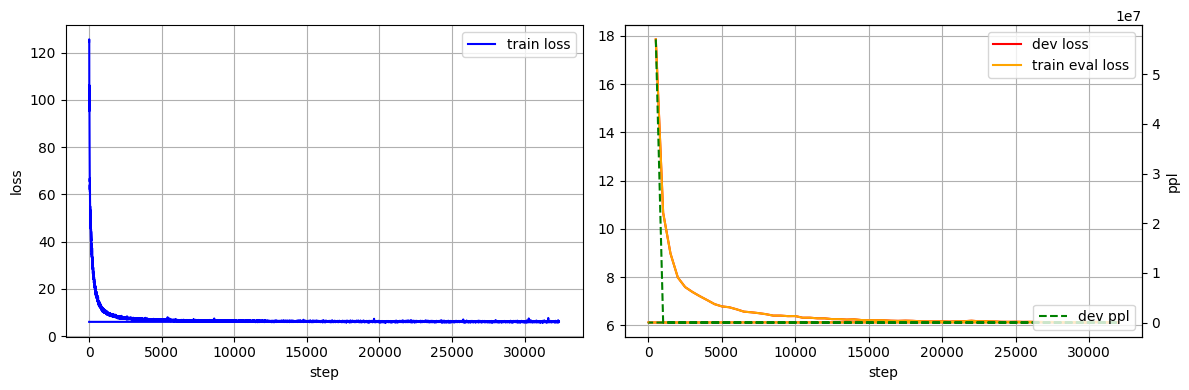

In [ ]:
model.train()
for step, (xb, yb) in enumerate(loader, 1):
    xb = xb.to(device, non_blocking=True)
    yb = yb.to(device, non_blocking=True)

    opt.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        loss = compute_loss(model, xb, yb)

    scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(opt)
    scaler.update()

    # Logging train loss
    train_steps.append(step)
    train_losses.append(loss.item())

    # --- EVAL ---
    if step % eval_every == 0:
        tl, tppl = evaluate(model, tokenizer, text_train_files, device,
                            block_size=256, batch_size=8, max_batches=eval_max_batches)
        dl, dppl = evaluate(model, tokenizer, text_test_files, device,
                            block_size=256, batch_size=8, max_batches=eval_max_batches)

        eval_steps.append(step)
        eval_train_loss.append(tl); eval_train_ppl.append(tppl)
        eval_dev_loss.append(dl);   eval_dev_ppl.append(dppl)

    # --- LIVE PLOTTING ---
    if step % log_every == 0:
        clear_output(wait=True)
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        axs[0].plot(train_steps, train_losses, label='train loss', color='blue')
        axs[0].set_xlabel('step'); axs[0].set_ylabel('loss'); axs[0].grid(True)
        axs[0].legend()

        if eval_steps:
            axs[1].plot(eval_steps, eval_dev_loss, label='dev loss', color='red')
            axs[1].plot(eval_steps, eval_train_loss, label='train eval loss', color='orange')
            axs[1].set_xlabel('step'); axs[1].grid(True)
            axs[1].legend()

            ax2 = axs[1].twinx()
            ax2.plot(eval_steps, eval_dev_ppl, label='dev ppl', color='green', linestyle='--')
            ax2.set_ylabel('ppl')
            ax2.legend(loc='lower right')

        plt.tight_layout()
        plt.show()


In [53]:
def get_next_token_probs(model, tokenizer, prefix: str):
    """
    Given a prefix string, return dict {token_str: prob} for all tokens.
    """
    model.eval()

    device = next(model.parameters()).device

    encoded = tokenizer.encode(prefix)
    input_ids = torch.tensor([encoded.ids], dtype=torch.long, device=device)  # (1, T)

    with torch.no_grad():
        logits = model(input_ids)  # (1, T, vocab_size)

    last_logits = logits[0, -1]  # (vocab_size,)

    probs = F.softmax(last_logits, dim=-1).cpu().numpy()

    vocab = tokenizer.get_vocab()
    id_to_token = {v: k for k, v in vocab.items()}
    tokens = [id_to_token[i] for i in range(len(probs))]

    return dict(zip(tokens, probs))

In [65]:
def generate_nucleus(model, prefix, nucleus=0.9, temperature=1.0, max_len=100):
    was_training = model.training
    model.eval()

    condition = lambda x: sum(x.values()) >= nucleus

    while True:
        token_probs = get_next_token_probs(model, tokenizer, prefix)

        nucleus_token_probs = sort_until_condition(token_probs, condition)
        tokens, probs = zip(*nucleus_token_probs.items())

        if temperature == 0:
            next_token = tokens[np.argmax(probs)]
        else:
            probs = np.array([p ** (1. / temperature) for p in probs])
            probs /= sum(probs)
            next_token = np.random.choice(tokens, p=probs)

        prefix += next_token

        if next_token == "[EOS]" or len(prefix) > max_len:
            break

    if was_training:
        model.train()

    return prefix

In [75]:
generate_nucleus(model, prefix="Given a prefix string, ", max_len=20)
# idk why, but smth went wrong((

'Given a prefix string, and'